In [1]:
import os, sys, shutil

# ── Définir le workspace ──────────────────────────────────────
WORKSPACE = '/mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI'
OMNIPARSER_DIR = os.path.join(WORKSPACE, 'OmniParser')

# ── Supprimer les anciens dossiers OmniParser en trop ─────────
for item in os.listdir(WORKSPACE):
    full = os.path.join(WORKSPACE, item)
    if 'omniparser' in item.lower() and os.path.isdir(full):
        shutil.rmtree(full)
        print(f"🗑️ Supprimé : {full}")

print("✅ Nettoyage OK")

🗑️ Supprimé : /mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI/OmniParser
✅ Nettoyage OK


In [2]:
!pip install ultralytics easyocr huggingface_hub Pillow matplotlib -q
print("✅ Dépendances OK")

✅ Dépendances OK


In [3]:
import os, sys, shutil
from huggingface_hub import hf_hub_download

WORKSPACE     = '/mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI'
OMNIPARSER_DIR = os.path.join(WORKSPACE, 'OmniParser')

# ── 1. Cloner OmniParser ──────────────────────────────────────
if not os.path.exists(OMNIPARSER_DIR):
    os.chdir(WORKSPACE)
    os.system(f'git clone https://github.com/microsoft/OmniParser.git {OMNIPARSER_DIR}')
    print("✅ OmniParser cloné")
else:
    print("✅ OmniParser déjà présent")

os.chdir(OMNIPARSER_DIR)
sys.path.insert(0, OMNIPARSER_DIR)
print("📍 Working dir:", os.getcwd())

# ── 2. Télécharger les poids ──────────────────────────────────
WEIGHTS = {
    "icon_detect/model.pt":               "weights/icon_detect/model.pt",
    "icon_detect/model.yaml":             "weights/icon_detect/model.yaml",
    "icon_caption/config.json":           "weights/icon_caption_florence/config.json",
    "icon_caption/generation_config.json":"weights/icon_caption_florence/generation_config.json",
    "icon_caption/model.safetensors":     "weights/icon_caption_florence/model.safetensors",
}

for hf_path, local_path in WEIGHTS.items():
    os.makedirs(os.path.dirname(local_path), exist_ok=True)
    if not os.path.exists(local_path):
        print(f"⏳ Téléchargement {hf_path}...")
        tmp = hf_hub_download(repo_id="microsoft/OmniParser-v2.0", filename=hf_path)
        shutil.copy(tmp, local_path)
        print(f"✅ {local_path} OK")
    else:
        size = os.path.getsize(local_path) / 1024 / 1024
        print(f"✅ Déjà présent : {local_path} ({size:.1f} MB)")

print("\n🎉 Setup complet !")

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cloning into '/mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI/OmniParser'...


✅ weights/icon_detect/model.pt OK
⏳ Téléchargement icon_detect/model.yaml...
✅ weights/icon_detect/model.yaml OK
⏳ Téléchargement icon_caption/config.json...
✅ weights/icon_caption_florence/config.json OK
⏳ Téléchargement icon_caption/generation_config.json...
✅ weights/icon_caption_florence/generation_config.json OK
⏳ Téléchargement icon_caption/model.safetensors...
✅ weights/icon_caption_florence/model.safetensors OK

🎉 Setup complet !


In [4]:
from ultralytics import YOLO
import easyocr

model  = YOLO('weights/icon_detect/model.pt')
reader = easyocr.Reader(['fr', 'en'])
print("✅ OmniParser (YOLO) chargé")
print("✅ EasyOCR chargé")

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


✅ OmniParser (YOLO) chargé
✅ EasyOCR chargé


In [5]:
import json, os, numpy as np
from PIL import Image

JSON_PATH      = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI/practice_data.json"
SCREENS_DIR    = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI/screens"
IOU_THRESHOLD  = 0.3
CONF_THRESHOLD = 0.5

def pct_to_px(pos, W, H):
    x = pos["x"] / 100 * W
    y = pos["y"] / 100 * H
    w = pos["width"]  / 100 * W
    h = pos["height"] / 100 * H
    return [x, y, x+w, y+h]

def compute_iou(A, B):
    xA, yA = max(A[0], B[0]), max(A[1], B[1])
    xB, yB = min(A[2], B[2]), min(A[3], B[3])
    inter  = max(0, xB-xA) * max(0, yB-yA)
    union  = (A[2]-A[0])*(A[3]-A[1]) + (B[2]-B[0])*(B[3]-B[1]) - inter
    return inter/union if union > 0 else 0

# Charger annotations JSON
with open(JSON_PATH) as f:
    data = json.load(f)

annotations = {}
for session in data["practice_sessions"]:
    for col in session["collections"]:
        for img in col["interactive_images"]:
            if not img["fields"]:
                continue
            W, H = img["screenshot_width"], img["screenshot_height"]
            annotations[img["image_id"]] = {
                "fields": [{"name": f["name"], "bbox": pct_to_px(f["position"], W, H)} for f in img["fields"]],
                "W": W, "H": H
            }

print(f"✅ {len(annotations)} images annotées chargées")

# Évaluation
results_all = []

for img_file in os.listdir(SCREENS_DIR):
    if not img_file.endswith(".png"):
        continue
    image_id = img_file.replace(".png", "")
    if image_id not in annotations:
        continue

    img_path  = os.path.join(SCREENS_DIR, img_file)
    gt_boxes  = [f["bbox"] for f in annotations[image_id]["fields"]]

    det        = model(img_path, verbose=False)
    pred_boxes = [[*b.xyxy[0].tolist()] for b in det[0].boxes if float(b.conf) >= CONF_THRESHOLD]

    matched_gt, matched_pred = set(), set()
    for gi, gt in enumerate(gt_boxes):
        best_iou, best_pi = 0, -1
        for pi, pred in enumerate(pred_boxes):
            iou = compute_iou(gt, pred)
            if iou > best_iou:
                best_iou, best_pi = iou, pi
        if best_iou >= IOU_THRESHOLD and best_pi not in matched_pred:
            matched_gt.add(gi)
            matched_pred.add(best_pi)

    TP = len(matched_gt)
    FP = len(pred_boxes) - len(matched_pred)
    FN = len(gt_boxes)   - TP
    P  = TP/(TP+FP) if (TP+FP) > 0 else 0
    R  = TP/(TP+FN) if (TP+FN) > 0 else 0
    F1 = 2*P*R/(P+R) if (P+R) > 0 else 0

    results_all.append({"image_id": image_id, "GT": len(gt_boxes),
                         "Det": len(pred_boxes), "TP": TP, "FP": FP, "FN": FN,
                         "P": round(P,3), "R": round(R,3), "F1": round(F1,3)})
    print(f"[{image_id[:30]}]  GT={len(gt_boxes)}  Det={len(pred_boxes)}  TP={TP}  P={P:.2f}  R={R:.2f}  F1={F1:.2f}")

# Résultats globaux
tTP = sum(r["TP"] for r in results_all)
tFP = sum(r["FP"] for r in results_all)
tFN = sum(r["FN"] for r in results_all)
P_g = tTP/(tTP+tFP) if (tTP+tFP)>0 else 0
R_g = tTP/(tTP+tFN) if (tTP+tFN)>0 else 0
F_g = 2*P_g*R_g/(P_g+R_g) if (P_g+R_g)>0 else 0
model_mb = os.path.getsize("weights/icon_detect/model.pt")/1024/1024

print(f"""
{'='*55}
  RÉSULTATS GLOBAUX  (IoU≥{IOU_THRESHOLD}, conf≥{CONF_THRESHOLD})
{'='*55}
  Images évaluées : {len(results_all)}
  Champs annotés  : {tTP+tFN}
  TP={tTP}  FP={tFP}  FN={tFN}
  Precision : {P_g:.3f}  ({P_g*100:.1f}%)
  Recall    : {R_g:.3f}  ({R_g*100:.1f}%)
  F1 Score  : {F_g:.3f}  ({F_g*100:.1f}%)
  Poids modèle : {model_mb:.1f} MB
{'='*55}
""")

✅ 23 images annotées chargées
[img_1767525774023]  GT=5  Det=51  TP=1  P=0.02  R=0.20  F1=0.04
[img_1767540423106]  GT=3  Det=49  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767541016812]  GT=2  Det=48  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767541389301]  GT=1  Det=47  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767542245506]  GT=1  Det=46  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767551755550]  GT=3  Det=53  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767551919967]  GT=1  Det=44  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767552014121]  GT=5  Det=47  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767552228211]  GT=1  Det=45  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767552400703]  GT=2  Det=53  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767552548532]  GT=1  Det=50  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767552632022]  GT=1  Det=48  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767552714000]  GT=2  Det=50  TP=0  P=0.00  R=0.00  F1=0.00
[img_1767552835774]  GT=2  Det=29  TP=1  P=0.03  R=0.50  F1=0.06
[img_1767553380140]  GT=1  Det=50  TP=0  P=0.00  R=0.00  F1=

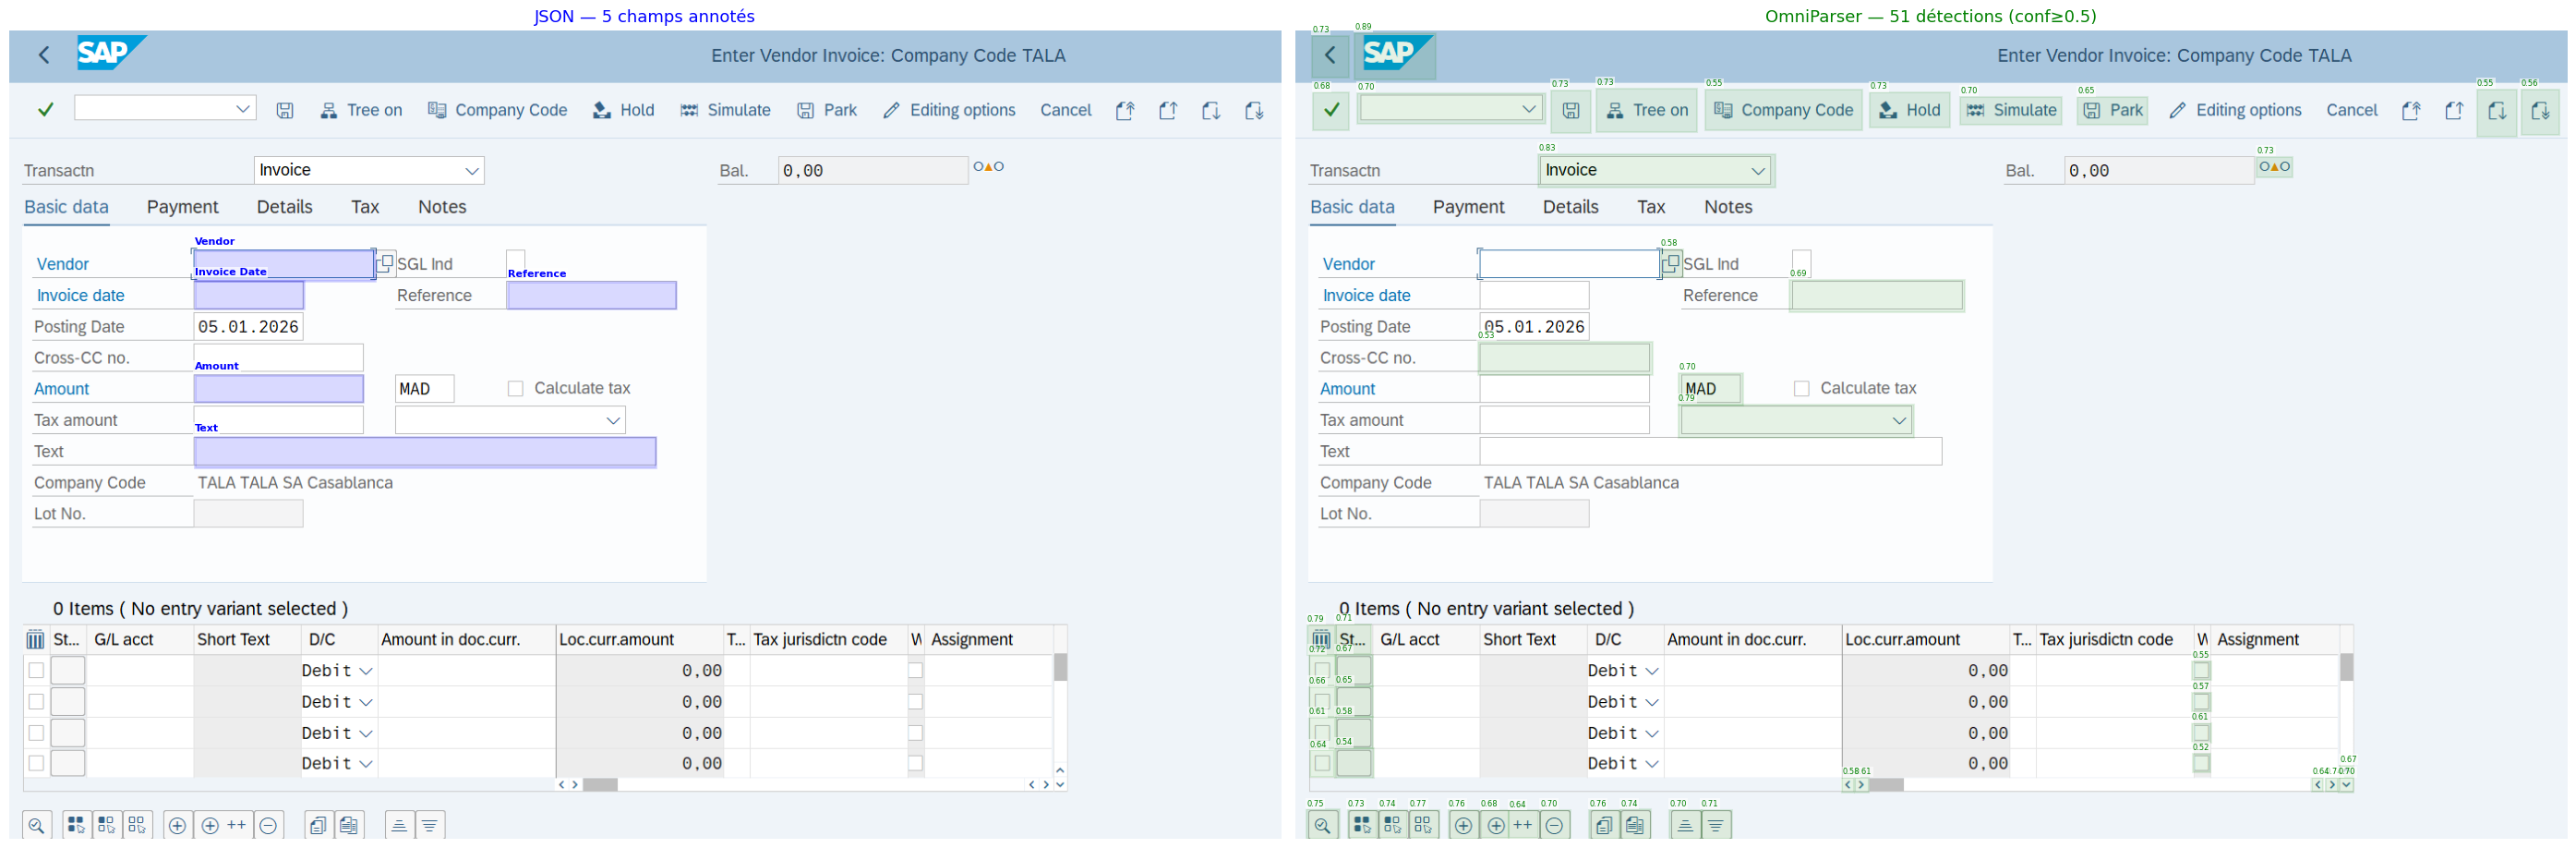

✅ JSON : 5 champs | OmniParser : 51 détections


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import json, os

# ── Config ────────────────────────────────────────────────────
IMAGE_ID   = "img_1767525774023"   # change ici pour tester d'autres images
SCREENS_DIR = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI/screens"
JSON_PATH   = "/mnt/batch/tasks/shared/LS_root/mounts/clusters/erp-benchmark-cpu/code/Users/Alae.ELMAHDAOUI/practice_data.json"
CONF_THRESHOLD = 0.5

# ── Charger l'image ───────────────────────────────────────────
img_path = os.path.join(SCREENS_DIR, f"{IMAGE_ID}.png")
img = Image.open(img_path)
W, H = img.size

# ── Charger annotations JSON pour cette image ─────────────────
with open(JSON_PATH) as f:
    data = json.load(f)

gt_fields = []
for session in data["practice_sessions"]:
    for col in session["collections"]:
        for img_data in col["interactive_images"]:
            if img_data["image_id"] == IMAGE_ID:
                for field in img_data["fields"]:
                    pos = field["position"]
                    gt_fields.append({
                        "name": field["name"],
                        "x":    pos["x"] / 100 * W,
                        "y":    pos["y"] / 100 * H,
                        "w":    pos["width"]  / 100 * W,
                        "h":    pos["height"] / 100 * H,
                    })

# ── Détections OmniParser ─────────────────────────────────────
det = model(img_path, verbose=False)
omni_boxes = []
for box in det[0].boxes:
    if float(box.conf) >= CONF_THRESHOLD:
        x1,y1,x2,y2 = box.xyxy[0].tolist()
        omni_boxes.append({
            "conf": float(box.conf),
            "x": x1, "y": y1, "w": x2-x1, "h": y2-y1
        })

# ── Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(28, 14))

for ax, title in zip(axes, ["JSON — Ground Truth", "OmniParser — Détections"]):
    ax.imshow(img)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')

# --- Gauche : JSON (boîtes BLEUES) ---
for f in gt_fields:
    rect = patches.Rectangle(
        (f["x"], f["y"]), f["w"], f["h"],
        linewidth=2, edgecolor='blue', facecolor='blue', alpha=0.15
    )
    axes[0].add_patch(rect)
    axes[0].text(
        f["x"], f["y"] - 6, f["name"],
        color='blue', fontsize=8, fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.7, pad=1, edgecolor='none')
    )

axes[0].set_title(f"JSON — {len(gt_fields)} champs annotés", fontsize=13, color='blue')

# --- Droite : OmniParser (boîtes VERTES) ---
for b in omni_boxes:
    rect = patches.Rectangle(
        (b["x"], b["y"]), b["w"], b["h"],
        linewidth=1.5, edgecolor='green', facecolor='green', alpha=0.1
    )
    axes[1].add_patch(rect)
    axes[1].text(
        b["x"], b["y"] - 4, f"{b['conf']:.2f}",
        color='green', fontsize=6,
        bbox=dict(facecolor='white', alpha=0.6, pad=1, edgecolor='none')
    )

axes[1].set_title(f"OmniParser — {len(omni_boxes)} détections (conf≥{CONF_THRESHOLD})", fontsize=13, color='green')

plt.tight_layout()
plt.savefig("comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ JSON : {len(gt_fields)} champs | OmniParser : {len(omni_boxes)} détections")